# Tamil Dialect Classification - Model Comparison

Compares F1 scores across all model variants and generates a summary plot.

In [1]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import numpy as np

In [2]:
# Base directory
BASE_DIR = "E:/Work/My Papers/Dravidian Lang Tech 2026/Dialect based speech processing/Dialect Classification"

# Variant configurations: folder_name -> (short_name, full_description, model_type)
VARIANTS = {
    "1_original_average_attentive_entire": (
        "1. Orig Avg+Att (Entire)",
        "Facebook XLSR-53 + Average & Attentive Pooling + Fine-tune Top 4 Layers",
        "Original"
    ),
    "2_finetuned_average_attentive": (
        "2. Tamil Avg+Att",
        "Tamil Wav2Vec + Average & L2-Attentive Pooling (Frozen)",
        "Tamil"
    ),
    "3_original_average": (
        "3. Orig Average",
        "Facebook XLSR-53 + Average Pooling (Frozen)",
        "Original"
    ),
    "4_original_attentive": (
        "4. Orig Attentive",
        "Facebook XLSR-53 + L2-Attentive Pooling (Frozen)",
        "Original"
    ),
    "5_finetuned_average": (
        "5. Tamil Average",
        "Tamil Wav2Vec + Average Pooling (Frozen)",
        "Tamil"
    ),
    "6_finetuned_attentive": (
        "6. Tamil Attentive",
        "Tamil Wav2Vec + L2-Attentive Pooling (Frozen)",
        "Tamil"
    ),
    "7_original_average_attentive": (
        "7. Orig Avg+Att",
        "Facebook XLSR-53 + Average & L2-Attentive Pooling (Frozen)",
        "Original"
    ),
    "8_original_learned_attentive": (
        "8. Orig Learned Att",
        "Facebook XLSR-53 + Learned Attentive Pooling (Frozen)",
        "Original"
    ),
    "9_original_learned_average_attentive": (
        "9. Orig Learned Avg+Att",
        "Facebook XLSR-53 + Average & Learned Attentive Pooling (Frozen)",
        "Original"
    ),
    "10_finetuned_learned_attentive": (
        "10. Tamil Learned Att",
        "Tamil Wav2Vec + Learned Attentive Pooling (Frozen)",
        "Tamil"
    ),
    "11_finetuned_learned_average_attentive": (
        "11. Tamil Learned Avg+Att",
        "Tamil Wav2Vec + Average & Learned Attentive Pooling (Frozen)",
        "Tamil"
    ),
    "12_finetuned_learned_attentive_entire": (
        "12. Tamil Learned Att (Entire)",
        "Tamil Wav2Vec + Learned Attentive Pooling + Fine-tune Top 4 Layers",
        "Tamil"
    )
}

In [3]:
def find_best_checkpoint(folder_path):
    """Find the best model checkpoint in a variant folder."""
    # Look for checkpoints in train_data/checkpoints_N or train_data/checkpoints/
    checkpoint_patterns = [
        os.path.join(folder_path, "train_data", "checkpoints_*", "best_model.pth"),
        os.path.join(folder_path, "train_data", "checkpoints", "*", "best_model.pth"),
    ]
    
    for pattern in checkpoint_patterns:
        matches = glob(pattern)
        if matches:
            # Return the last one (highest number)
            return sorted(matches)[-1]
    
    return None


def load_f1_score(checkpoint_path):
    """Load F1 score from checkpoint."""
    try:
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        return checkpoint.get('best_metric', 0.0)
    except Exception as e:
        print(f"Error loading {checkpoint_path}: {e}")
        return None

In [4]:
# Collect results
results = []

for folder_name, (short_name, description, model_type) in VARIANTS.items():
    folder_path = os.path.join(BASE_DIR, folder_name)
    
    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_name}")
        continue
    
    checkpoint_path = find_best_checkpoint(folder_path)
    
    if checkpoint_path:
        f1_score = load_f1_score(checkpoint_path)
        if f1_score is not None:
            results.append({
                'variant': short_name,
                'folder': folder_name,
                'f1_score': f1_score,
                'model_type': model_type,
                'description': description,
                'checkpoint_path': checkpoint_path
            })
            print(f"{short_name}: F1 = {f1_score:.4f}")
        else:
            print(f"{short_name}: Failed to load F1")
    else:
        print(f"{folder_name}: No checkpoint found")

print(f"\nTotal variants with results: {len(results)}")

1. Orig Avg+Att (Entire): F1 = 0.2724
2. Tamil Avg+Att: F1 = 0.7691
3. Orig Average: F1 = 0.1335
4. Orig Attentive: F1 = 0.1853
5. Tamil Average: F1 = 0.8104
6. Tamil Attentive: F1 = 0.8210
7. Orig Avg+Att: F1 = 0.1334
8. Orig Learned Att: F1 = 0.6303
9. Orig Learned Avg+Att: F1 = 0.7097
10. Tamil Learned Att: F1 = 0.8458
11. Tamil Learned Avg+Att: F1 = 0.8471
12. Tamil Learned Att (Entire): F1 = 0.9235

Total variants with results: 12


In [5]:
# Create DataFrame
df = pd.DataFrame(results)
df = df.sort_values('f1_score', ascending=False).reset_index(drop=True)

# Save to CSV
csv_path = os.path.join(BASE_DIR, "Final_Results", "model_comparison.csv")
df.to_csv(csv_path, index=False)
print(f"Saved results to {csv_path}")

df

Saved results to E:/Work/My Papers/Dravidian Lang Tech 2026/Dialect based speech processing/Dialect Classification\Final_Results\model_comparison.csv


,variant,folder,f1_score,model_type,description,checkpoint_path
0,12. Tamil Learned Att (Entire),12_finetuned_learned_attentive_entire,0.923457,Tamil,Tamil Wav2Vec + Learned Attentive Pooling + Fi...,E:/Work/My Papers/Dravidian Lang Tech 2026/Dia...
1,11. Tamil Learned Avg+Att,11_finetuned_learned_average_attentive,0.847082,Tamil,Tamil Wav2Vec + Average & Learned Attentive Po...,E:/Work/My Papers/Dravidian Lang Tech 2026/Dia...
2,10. Tamil Learned Att,10_finetuned_learned_attentive,0.845778,Tamil,Tamil Wav2Vec + Learned Attentive Pooling (Fro...,E:/Work/My Papers/Dravidian Lang Tech 2026/Dia...
3,6. Tamil Attentive,6_finetuned_attentive,0.820957,Tamil,Tamil Wav2Vec + L2-Attentive Pooling (Frozen),E:/Work/My Papers/Dravidian Lang Tech 2026/Dia...
4,5. Tamil Average,5_finetuned_average,0.810406,Tamil,Tamil Wav2Vec + Average Pooling (Frozen),E:/Work/My Papers/Dravidian Lang Tech 2026/Dia...
5,2. Tamil Avg+Att,2_finetuned_average_attentive,0.769074,Tamil,Tamil Wav2Vec + Average & L2-Attentive Pooling...,E:/Work/My Papers/Dravidian Lang Tech 2026/Dia...
6,9. Orig Learned Avg+Att,9_original_learned_average_attentive,0.709748,Original,Facebook XLSR-53 + Average & Learned Attentive...,E:/Work/My Papers/Dravidian Lang Tech 2026/Dia...
7,8. Orig Learned Att,8_original_learned_attentive,0.630336,Original,Facebook XLSR-53 + Learned Attentive Pooling (...,E:/Work/My Papers/Dravidian Lang Tech 2026/Dia...
8,1. Orig Avg+Att (Entire),1_original_average_attentive_entire,0.272374,Original,Facebook XLSR-53 + Average & Attentive Pooling...,E:/Work/My Papers/Dravidian Lang Tech 2026/Dia...
9,4. Orig Attentive,4_original_attentive,0.185295,Original,Facebook XLSR-53 + L2-Attentive Pooling (Frozen),E:/Work/My Papers/Dravidian Lang Tech 2026/Dia...


Saved plot to E:/Work/My Papers/Dravidian Lang Tech 2026/Dialect based speech processing/Dialect Classification\Final_Results\model_comparison.png


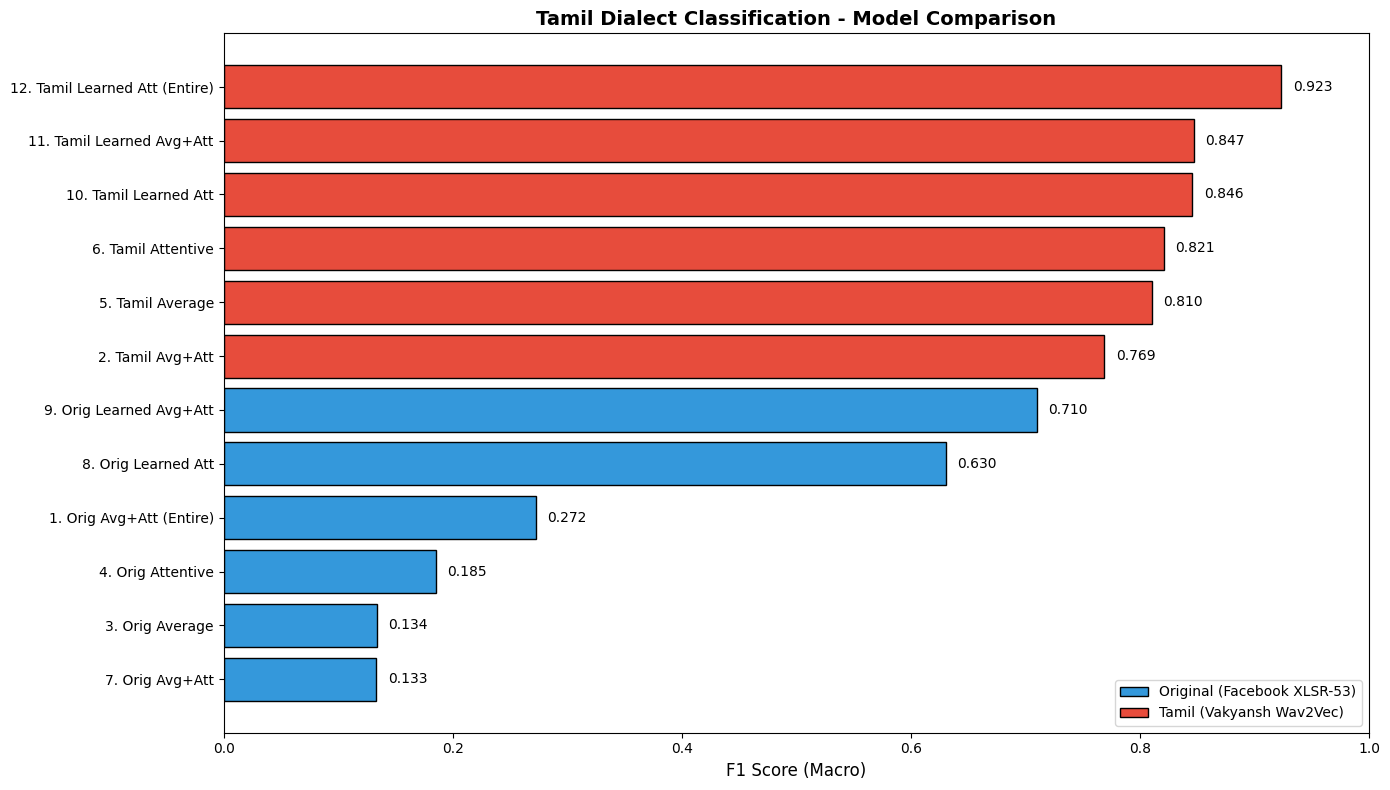

In [6]:
# Create bar plot
plt.figure(figsize=(14, 8))

# Sort by F1 score for plotting
df_sorted = df.sort_values('f1_score', ascending=True)

# Colors by model type
colors = ['#3498db' if t == 'Original' else '#e74c3c' for t in df_sorted['model_type']]

# Horizontal bar plot
bars = plt.barh(range(len(df_sorted)), df_sorted['f1_score'], color=colors, edgecolor='black')

# Labels
plt.yticks(range(len(df_sorted)), df_sorted['variant'])
plt.xlabel('F1 Score (Macro)', fontsize=12)
plt.title('Tamil Dialect Classification - Model Comparison', fontsize=14, fontweight='bold')

# Add F1 scores on bars
for i, (bar, f1) in enumerate(zip(bars, df_sorted['f1_score'])):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{f1:.3f}', va='center', fontsize=10)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', edgecolor='black', label='Original (Facebook XLSR-53)'),
    Patch(facecolor='#e74c3c', edgecolor='black', label='Tamil (Vakyansh Wav2Vec)')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.xlim(0, 1.0)
plt.tight_layout()

# Save plot
plot_path = os.path.join(BASE_DIR, "Final_Results", "model_comparison.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"Saved plot to {plot_path}")

plt.show()

In [7]:
# Legend table with full descriptions
print("\n" + "="*100)
print("MODEL VARIANT DESCRIPTIONS")
print("="*100)

for _, row in df.iterrows():
    print(f"\n{row['variant']}")
    print(f"  F1 Score: {row['f1_score']:.4f}")
    print(f"  {row['description']}")
    print(f"  Checkpoint: {row['checkpoint_path']}")


MODEL VARIANT DESCRIPTIONS

12. Tamil Learned Att (Entire)
  F1 Score: 0.9235
  Tamil Wav2Vec + Learned Attentive Pooling + Fine-tune Top 4 Layers
  Checkpoint: E:/Work/My Papers/Dravidian Lang Tech 2026/Dialect based speech processing/Dialect Classification\12_finetuned_learned_attentive_entire\train_data\checkpoints_1\best_model.pth

11. Tamil Learned Avg+Att
  F1 Score: 0.8471
  Tamil Wav2Vec + Average & Learned Attentive Pooling (Frozen)
  Checkpoint: E:/Work/My Papers/Dravidian Lang Tech 2026/Dialect based speech processing/Dialect Classification\11_finetuned_learned_average_attentive\train_data\checkpoints\train_1\best_model.pth

10. Tamil Learned Att
  F1 Score: 0.8458
  Tamil Wav2Vec + Learned Attentive Pooling (Frozen)
  Checkpoint: E:/Work/My Papers/Dravidian Lang Tech 2026/Dialect based speech processing/Dialect Classification\10_finetuned_learned_attentive\train_data\checkpoints\train_1\best_model.pth

6. Tamil Attentive
  F1 Score: 0.8210
  Tamil Wav2Vec + L2-Attentive Po